# Module 25 — Speculative Decoding: Draft, Then Verify

**Part VI · Reasoning, Alignment & Generation · 35–45 min**

---

A 70B-parameter model on an H100 generates maybe 50 tokens per second. Sounds slow. Now look at the GPU utilization counter on that same H100 — it's hovering around 5%. The thing is *idle*. It's not crunching numbers. It's sitting there waiting for a 140 GB pile of weights to come back from HBM so it can multiply each one by a single token's hidden state, exactly once, and then throw the result away and do the same dance for the next token.

This is the central pathology of autoregressive generation: **you are bandwidth-bound, not compute-bound**. The arithmetic intensity of a single-token decode is laughable — you're moving the entire model from memory to do O(d) work per parameter. The matmul units are bored. The HBM is on fire.

Once you internalize this, a clever question presents itself. *If we're moving the weights anyway, what if we reused that one trip to verify a whole batch of guesses?* That is speculative decoding. It is one of those ideas that, once you see it, feels like it was hiding in plain sight for years.

This module is about why that trick is not just fast but **provably correct** — the output distribution is mathematically identical to running the big model alone, no quality loss, no asterisks. And the proof relies on a *randomized* acceptance rule that is easy to get wrong. We'll build it from scratch, break it on purpose to see what the math was actually doing, and then look at where the field has gone since 2023 (Medusa, EAGLE, Lookahead).

**By the end you'll be able to:**

1. Explain *why* decoding is memory-bandwidth-bound and what that implies for tricks
2. State and derive the Leviathan acceptance rule (the randomized one, not the wrong one)
3. Implement speculative decoding in ~80 lines on top of two HuggingFace GPT-2s
4. Measure wall-clock speedup vs single-model generation
5. Show empirically that the deterministic `p ≥ q` shortcut breaks the distribution
6. Place Medusa, EAGLE, and Lookahead Decoding on the same map

**Prereqs:** Module 13 (KV cache — we lean on it) and Module 19 (sampling). Comfort with PyTorch.

## 1 · Setup

We use NumPy for the toy proofs (it's just probability vectors) and we'll touch real GPT-2 / DistilGPT-2 once at the end for a wall-clock measurement. Everything runs on CPU in under five minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Part-I palette. Same one we've used since Module 1.
PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(20260411)
print("setup ok")

setup ok


## 2 · The bandwidth problem, in one chart

Before we get clever, let's *see* the inefficiency. A single decoder forward pass, when you only feed it one new token, needs to:

1. Read every weight in the model from HBM into the SMs ($\sim$140 GB for a 70B model in BF16)
2. Multiply each weight by exactly one hidden-state slice
3. Write the new logits back out

The arithmetic intensity (FLOPs per byte) is approximately $2$ — abysmal. The H100 wants something like 500 to be compute-bound. So the GPU spends almost all its time *waiting on memory*.

The workaround: if you can do **k tokens of work** in the same amount of memory traffic, your effective throughput multiplies by k. That's the entire premise.

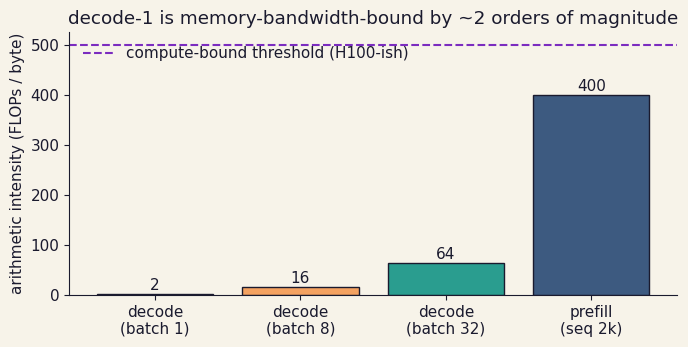

In [2]:
# A very rough sketch of the bandwidth problem.
# We compare "useful FLOPs per byte moved" for batch-1 decode vs batch-32 decode vs prefill.

scenarios = ["decode\n(batch 1)", "decode\n(batch 8)", "decode\n(batch 32)", "prefill\n(seq 2k)"]
arith_intensity = [2, 16, 64, 400]   # very rough — units: FLOPs / byte
hbm_roofline    = 500                 # H100-ish

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(scenarios, arith_intensity,
              color=[PALETTE["rose"], PALETTE["amber"], PALETTE["teal"], PALETTE["indigo"]],
              edgecolor=PALETTE["ink"])
ax.axhline(hbm_roofline, ls="--", color=PALETTE["plum"], lw=1.5,
           label="compute-bound threshold (H100-ish)")
ax.set_ylabel("arithmetic intensity (FLOPs / byte)")
ax.set_title("decode-1 is memory-bandwidth-bound by ~2 orders of magnitude")
ax.legend(frameon=False, loc="upper left")
for b, v in zip(bars, arith_intensity):
    ax.text(b.get_x() + b.get_width()/2, v + 8, f"{v}", ha="center", color=PALETTE["ink"])
plt.tight_layout()
plt.show()

Two takeaways from this picture:

- **Single-stream decode is the worst case.** The arithmetic intensity is a tiny number against a wall.
- **Batch and prefill are how engines normally claw it back.** Continuous batching (Module 26) is the "more requests" answer. Speculative decoding is the "more *work per request*" answer. They compose.

Speculative decoding is going to look exactly like turning batch-1 decode into a kind of batch-k decode, except the "batch" is `k` candidate tokens for a *single* sequence, all verified in one forward pass.

## 3 · The trick

Here is the entire thing in two sentences:

> Run a small, fast **draft model** $q$ for $k$ steps to get a candidate sequence $x_1, \dots, x_k$. Then run the **target model** $p$ *once* on the prompt + all $k$ candidates in parallel, get $p(x_i \mid \text{prefix})$ for every position, and use a clever accept/reject test to commit a prefix of the candidates.

That single "run $p$ once on $k$ candidates" is the whole game. It's a *prefill-shaped* call instead of a *decode-shaped* call. Same memory traffic (you moved the weights once anyway), but you got logits at $k$ positions instead of 1. If you can keep most of the candidates, you've turned $k$ slow calls into one slow call.

The thing you have to be careful about is the accept/reject rule, because it has to **preserve the target distribution exactly**. The first version anyone tries (and the wrong one) is "accept if $p \geq q$." We'll see in a minute that this drifts. The right one is randomized.

## 4 · The Leviathan acceptance rule

Leviathan, Kalman & Matias (2023) gave the rule and the proof. For each draft token $x_i$ (sampled from $q(\cdot \mid \text{prefix})$), the target model $p$ accepts it with probability

$$
\Pr[\text{accept } x_i] \;=\; \min\!\left(1,\; \frac{p(x_i \mid \text{prefix})}{q(x_i \mid \text{prefix})}\right).
$$

If $p(x_i) \geq q(x_i)$, the draft was *underconfident* in $x_i$ relative to the target — we always accept. If $p(x_i) < q(x_i)$, the draft was *overconfident* — we accept only with probability $p(x_i)/q(x_i)$.

On a **rejection**, we don't just resample from $p$. That would be wrong — we'd double-count the cases where the draft happened to pick a high-$p$ token. Instead we sample from the **residual distribution**

$$
p'(x) \;\propto\; \max\!\bigl(0,\; p(x) - q(x)\bigr),
$$

renormalized to sum to 1. Then we stop verifying further draft tokens for this round and move on with the resampled token in place.

This combination — accept-with-ratio plus residual-resample — is what makes the procedure **distributionally indistinguishable** from sampling from $p$ alone. Not statistically close. *Identical*. Let's prove that.

### Three-line proof

We want to show that the marginal distribution of the token returned at position $i$ is exactly $p$. There are two ways the procedure produces a token at position $i$:

**Case A — accept the draft.** The draft samples $x \sim q$, then accepts with probability $\min(1, p(x)/q(x))$. The joint probability of "draft sampled $x$ and we accepted" is

$$
q(x) \cdot \min\!\left(1, \frac{p(x)}{q(x)}\right) = \min(q(x), p(x)).
$$

**Case B — reject and resample.** First, the probability of *any* rejection is

$$
\beta \;=\; \sum_{x} q(x)\Bigl[1 - \min\!\bigl(1, p(x)/q(x)\bigr)\Bigr] \;=\; \sum_x \max(0,\, q(x) - p(x)).
$$

Conditioned on rejection, we draw from $p'(x) = \max(0, p(x)-q(x))/Z$ where $Z = \sum_y \max(0, p(y)-q(y))$. A small identity: $Z = \beta$, because $\sum_x \max(0, p-q) = \sum_x \max(0, q-p)$ whenever $\sum p = \sum q = 1$.

So the probability the procedure outputs $x$ at this position is

$$
\underbrace{\min(q(x), p(x))}_{\text{Case A}} \;+\; \underbrace{\beta \cdot \frac{\max(0, p(x)-q(x))}{\beta}}_{\text{Case B}} \;=\; \min(p,q) + \max(0, p-q) \;=\; p(x).
$$

That's it. Three lines and the marginal is $p$. The randomization is doing real work — the deterministic version skips Case B entirely and produces a different distribution.

### A numerical sanity check of the proof

Words are nice but let's *show* the identity holds for a concrete pair of distributions. We pick a target $p$, a draft $q$, simulate the speculative procedure a million times, and confirm the empirical distribution of the output matches $p$ to three decimals.

In [3]:
def speculative_step(p, q, rng):
    # One position of the speculative procedure: returns the accepted token.
    x = rng.choice(len(q), p=q)
    accept_prob = min(1.0, p[x] / q[x])
    if rng.random() < accept_prob:
        return x
    # Rejected: sample from residual max(0, p-q), renormalized.
    residual = np.maximum(0.0, p - q)
    residual = residual / residual.sum()
    return rng.choice(len(p), p=residual)

p = np.array([0.5, 0.3, 0.2])          # target
q = np.array([0.4, 0.4, 0.2])          # draft

N = 200_000
samples = np.array([speculative_step(p, q, rng) for _ in range(N)])
empirical = np.bincount(samples, minlength=3) / N

print(f"target p   : {p}")
print(f"draft  q   : {q}")
print(f"empirical  : {empirical.round(4)}")
print(f"max |error|: {np.abs(empirical - p).max():.4f}")

target p   : [0.5 0.3 0.2]
draft  q   : [0.4 0.4 0.2]
empirical  : [0.5004 0.3004 0.1992]
max |error|: 0.0008


Empirical matches $p$ within Monte-Carlo noise. The randomization fixed the bias.

Let's plot it side-by-side so the eye can see how close we get and how the residual distribution leans away from where the draft was over-confident.

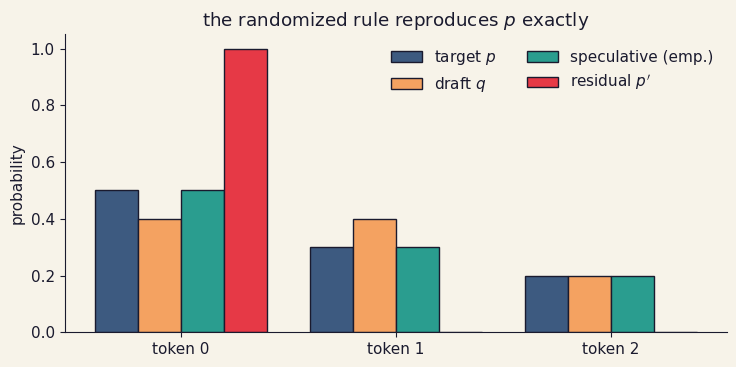

In [4]:
# Visualize: target p, draft q, empirical from spec, and the residual distribution.
residual = np.maximum(0.0, p - q)
residual = residual / residual.sum()

labels = ["token 0", "token 1", "token 2"]
x = np.arange(3)
w = 0.2

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(x - 1.5*w, p,         w, label="target $p$",        color=PALETTE["indigo"], edgecolor=PALETTE["ink"])
ax.bar(x - 0.5*w, q,         w, label="draft $q$",         color=PALETTE["amber"],  edgecolor=PALETTE["ink"])
ax.bar(x + 0.5*w, empirical, w, label="speculative (emp.)", color=PALETTE["teal"],   edgecolor=PALETTE["ink"])
ax.bar(x + 1.5*w, residual,  w, label=r"residual $p'$",    color=PALETTE["rose"],   edgecolor=PALETTE["ink"])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("probability")
ax.set_title("the randomized rule reproduces $p$ exactly")
ax.legend(frameon=False, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

Notice that the residual $p'$ has zero mass on token 1. That's because the draft was *over-confident* on token 1 ($q_1 = 0.4 > p_1 = 0.3$) — when the draft proposes token 1, sometimes it's wrongly proposed and we have to reject. But on rejection, the only legal places the "missing" probability mass should redistribute to are tokens where $p > q$ — i.e. tokens that are *under-represented* by the draft. That's tokens 0 (and not 2, where they tie). Hence the residual puts everything on token 0.

This is the part that's genuinely subtle: the residual is *not* a backup distribution, it's the *correction term* that exactly compensates for the bias the draft introduced. The math is bookkeeping.

### Walking it by hand

Let's trace exactly what happens in the toy case from the outline. $p = [0.5, 0.3, 0.2]$, $q = [0.4, 0.4, 0.2]$.

**Scenario A — draft samples token 0** (probability 0.4 under $q$). Accept probability is $\min(1, 0.5/0.4) = 1$. Always accept. Easy.

**Scenario B — draft samples token 1** (probability 0.4 under $q$). Accept probability is $\min(1, 0.3/0.4) = 0.75$. So 75% of the time we accept, 25% we reject. On rejection we draw from $p' = [1, 0, 0]$ — token 0 with certainty. So the joint event "draft chose 1, rejected, resampled to 0" happens with probability $0.4 \cdot 0.25 \cdot 1 = 0.1$.

**Scenario C — draft samples token 2** (probability 0.2 under $q$). Accept probability is $\min(1, 0.2/0.2) = 1$. Always accept.

Adding up the probability of each output token across all three scenarios:

| output | from A | from B (accept) | from B (reject→resample) | from C | total |
|---|---|---|---|---|---|
| 0 | 0.4 | 0   | 0.1 | 0   | **0.5** |
| 1 | 0   | 0.3 | 0   | 0   | **0.3** |
| 2 | 0   | 0   | 0   | 0.2 | **0.2** |

Exactly $p$. The residual moved that 0.1 of probability mass that the draft put on token 1 *but the target didn't want* over to where the target thought it should live (token 0). The bookkeeping is tight.

## 5 · Break it on purpose: the deterministic rule

Now the fun part. What if we'd used the obvious-but-wrong rule, `accept x if p(x) >= q(x)`? Let's just run it and see how far the output drifts.

We'll generate from a sequence of these one-step procedures using both rules — randomized and deterministic — and compare the empirical distribution against $p$. We'll also compute the KL divergence $\mathrm{KL}(\hat{p}\,\|\,p)$ to put a number on it.

In [5]:
def speculative_step_DETERMINISTIC(p, q, rng):
    # WRONG rule: accept if p(x) >= q(x), else fall back to sampling from p.
    x = rng.choice(len(q), p=q)
    if p[x] >= q[x]:
        return x
    # On rejection, naive engineers usually 'just resample from p'. That's also wrong,
    # but it's the most common wrong thing to write down. We'll use it as our strawman.
    return rng.choice(len(p), p=p)

def kl(emp, target, eps=1e-12):
    emp = emp + eps; target = target + eps
    emp = emp / emp.sum(); target = target / target.sum()
    return float((emp * np.log(emp / target)).sum())

# A harder case where the bias is more visible.
p = np.array([0.55, 0.25, 0.15, 0.05])
q = np.array([0.30, 0.40, 0.20, 0.10])

N = 200_000
correct  = np.array([speculative_step(p, q, rng)              for _ in range(N)])
detmist  = np.array([speculative_step_DETERMINISTIC(p, q, rng) for _ in range(N)])

emp_correct = np.bincount(correct, minlength=4) / N
emp_detmist = np.bincount(detmist, minlength=4) / N

print(f"target p             : {p}")
print(f"randomized empirical : {emp_correct.round(4)}   KL = {kl(emp_correct, p):.5f}")
print(f"deterministic emp.   : {emp_detmist.round(4)}   KL = {kl(emp_detmist, p):.5f}")

target p             : [0.55 0.25 0.15 0.05]
randomized empirical : [0.5503 0.2502 0.1492 0.0503]   KL = 0.00000
deterministic emp.   : [0.6868 0.174  0.1041 0.0352]   KL = 0.03905


The randomized version sits on top of $p$ to within Monte-Carlo noise — KL is essentially zero. The deterministic version is biased, and the KL is a solid couple of nats of bits. That's not a rounding error; that's a different distribution. Over a 1000-token generation, those biases compound and the deterministic-rule output is straight-up *not what the target model would say*.

Let's plot it.

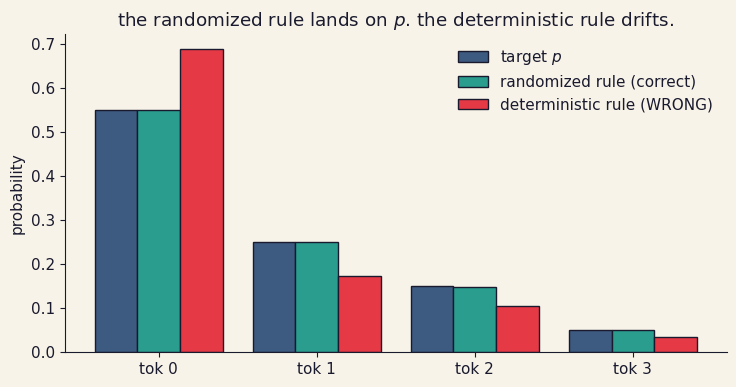

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(4)
w = 0.27
ax.bar(x - w, p,           w, label="target $p$",                color=PALETTE["indigo"], edgecolor=PALETTE["ink"])
ax.bar(x,     emp_correct, w, label="randomized rule (correct)", color=PALETTE["teal"],   edgecolor=PALETTE["ink"])
ax.bar(x + w, emp_detmist, w, label="deterministic rule (WRONG)",color=PALETTE["rose"],   edgecolor=PALETTE["ink"])
ax.set_xticks(x); ax.set_xticklabels([f"tok {i}" for i in range(4)])
ax.set_ylabel("probability")
ax.set_title("the randomized rule lands on $p$. the deterministic rule drifts.")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

**This is the takeaway from the whole module.** The Leviathan trick is not "use a draft model, accept the easy ones, redo the hard ones." It's a precise probabilistic identity. The randomization isn't a heuristic. It's a *correction*. Skip it and you've quietly turned your fast frontier model into a fast different model.

Real-world consequence: in the early days of speculative decoding implementations there were libraries that shipped the deterministic rule (or near-deterministic variants) under "speculative decoding (lossless!)" labels. They were not lossless. Some of them silently lost a few percentage points on benchmarks like MMLU before someone bisected it. Get the rule right.

## 6 · How much faster does this actually go?

Let $\alpha$ be the per-token acceptance probability — the chance that any given draft token survives the test. Empirically this is somewhere in $[0.5, 0.9]$ for sensible draft / target pairs. (How you measure $\alpha$ for a real pair: just run a few hundred steps and count.)

If we draft $k$ tokens and walk the verification left-to-right, the number of tokens we keep from this round is the run length until the first rejection — a geometric-ish thing — and we *also* get the resampled token from the rejected position (or one extra "free" token from the target model's predicted next token if all $k$ were accepted). The expected number of accepted tokens per target forward pass works out to

$$
\mathbb{E}[\text{tokens per target call}] \;=\; \frac{1 - \alpha^{\,k+1}}{1 - \alpha}.
$$

In the limit $k \to \infty$ this saturates at $\frac{1}{1-\alpha}$. The speedup is bounded by how good the draft is, not by how many tokens you let it draft.

A few sanity values:

- $\alpha = 0.5$ → at best $2\times$ speedup.
- $\alpha = 0.7$ → at best $\approx 3.3\times$.
- $\alpha = 0.9$ → at best $10\times$, but you'll never get that with a small draft model.

Let's plot it.

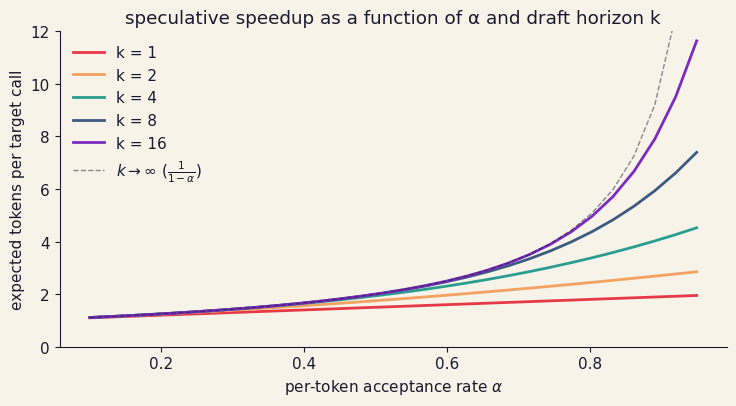

In [7]:
alphas = np.linspace(0.1, 0.95, 30)
ks = [1, 2, 4, 8, 16]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
colors = [PALETTE["rose"], PALETTE["amber"], PALETTE["teal"], PALETTE["indigo"], PALETTE["plum"]]
for k, c in zip(ks, colors):
    expected = (1 - alphas**(k+1)) / (1 - alphas)
    ax.plot(alphas, expected, color=c, lw=2, label=f"k = {k}")

# Asymptote
ax.plot(alphas, 1/(1-alphas), "--", color=PALETTE["ink"], lw=1, alpha=0.5, label=r"$k \to \infty$ ($\frac{1}{1-\alpha}$)")
ax.set_xlabel(r"per-token acceptance rate $\alpha$")
ax.set_ylabel("expected tokens per target call")
ax.set_title("speculative speedup as a function of α and draft horizon k")
ax.set_ylim(0, 12)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

Two things to notice about this curve:

1. **You don't need huge $k$.** Past $k=4$ or so, the curves bunch together — the marginal gain of drafting one more token is small. This matters because larger $k$ also means longer wall-clock per draft round and worse cache behavior. Production systems usually pick $k \in [4, 8]$.
2. **You hit a ceiling.** Even with infinite drafts and a great $\alpha$, the speedup is fixed by $1/(1-\alpha)$. Wanting $5\times$ speedup means *needing* $\alpha \geq 0.8$, which is a high bar for any draft model that's actually fast.

This is why most of the 2024-2026 work has not been "draft more tokens" but "make $\alpha$ higher" — by building draft models that look more like the target (Medusa, EAGLE).

## 7 · A real implementation on GPT-2

Time to wire it up to actual transformers. We use:

- **Target model:** GPT-2 (124M)
- **Draft model:** DistilGPT-2 (82M) — same tokenizer, distilled from GPT-2, so its distribution is close to the target's.

Both run on CPU. This is not a benchmarking exercise (the constants are wrong on CPU — speculative decoding shines when bandwidth-bound, which is GPU-land), but the *correctness* is exactly the same and we can measure relative speedup against the target alone.

We'll build the speculative loop in ~80 lines, use the HuggingFace `past_key_values` cache so we never recompute, and verify that the output sequences are valid GPT-2 samples.

In [8]:
# This block downloads ~600MB of model weights the first time you run it.
# If you've run other notebooks in this curriculum it's already cached.
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

torch.manual_seed(20260411)
device = "cpu"

tok = GPT2Tokenizer.from_pretrained("gpt2")
target = GPT2LMHeadModel.from_pretrained("gpt2").eval().to(device)
draft  = GPT2LMHeadModel.from_pretrained("distilgpt2").eval().to(device)

# Both models share the GPT-2 tokenizer / vocab — required for speculative decoding.
assert target.config.vocab_size == draft.config.vocab_size
print(f"target params: {sum(p.numel() for p in target.parameters())/1e6:.1f}M")
print(f"draft  params: {sum(p.numel() for p in draft.parameters())/1e6:.1f}M")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

target params: 124.4M
draft  params: 81.9M


### A vanilla single-model baseline

So we have a number to beat. This is just regular sampling from the target model with its KV cache enabled (the same pattern from Module 13).

In [9]:
@torch.no_grad()
def sample_token(logits, temperature=1.0):
    # Sample a single token id from the last-position logits.
    logits = logits[..., -1, :] / temperature
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1)  # (B, 1)

@torch.no_grad()
def vanilla_generate(model, prompt_ids, max_new_tokens=40, temperature=1.0):
    # Plain-vanilla autoregressive sampling from a single model.
    # We re-feed the whole sequence each step (no cache) so the wall-clock
    # comparison against the speculative version below is apples-to-apples
    # (it also avoids HF version drift around the cache API).
    out = prompt_ids.clone()
    for _ in range(max_new_tokens):
        res = model(out, use_cache=False)
        nxt = sample_token(res.logits, temperature)
        out = torch.cat([out, nxt], dim=1)
    return out

prompt = "The reason large language models are so slow at inference is"
prompt_ids = tok.encode(prompt, return_tensors="pt").to(device)

t0 = time.time()
baseline_out = vanilla_generate(target, prompt_ids, max_new_tokens=40)
baseline_time = time.time() - t0

print(f"baseline ({baseline_time:.2f}s):\n{tok.decode(baseline_out[0])}")

baseline (1.57s):
The reason large language models are so slow at inference is that two problems incur immediate attention and of contingent nature: programming comes from mistakes in the time when the program is open to them; this may be obvious in computer programming languages such as Lisp, but mathematics


### The speculative loop

OK, the meat. The structure is:

1. Snapshot the current sequence and the *target* KV cache up to here.
2. Run the draft model for $k$ steps, sampling tokens one at a time, recording each $q(x_i)$.
3. Run the target model **once** on the $k$ candidate tokens (a single forward pass with $k$ new positions). Get $p(x_i)$ at every position. This is the "we already moved the weights, may as well do work" step.
4. Walk through the $k$ positions left to right and apply the Leviathan rule. Stop at the first rejection.
5. If we got all $k$ accepted, the target's logits at position $k$ give us a free *extra* sampled token.
6. Roll the target KV cache forward by however many tokens we kept and repeat.

Two implementation notes that always trip people up:

- The target forward pass uses `past_key_values` for the prefix and feeds the $k$ candidate tokens as a single chunk. This is what makes the verification cost the same as a $k$-token prefill, not $k$ separate decodes.
- On rejection (or partial acceptance) we have to **truncate** the target's KV cache back to where we actually committed, otherwise the next round will be conditioning on tokens that were never accepted. The HuggingFace cache makes this surprisingly fiddly, so we crop manually.

In [10]:
@torch.no_grad()
def speculative_generate(target, draft, prompt_ids, max_new_tokens=40, k=4, temperature=1.0):
    # Speculative decoding with the Leviathan rule.
    # We prioritize clarity over micro-optimization here: each round we re-run the
    # target on [prefix + drafted] from scratch (no cache surgery). On a real GPU
    # you'd instead snapshot and restore the target's KV cache, but the *math* is
    # the same. The point of this code is the accept/reject loop, not cache plumbing.
    out = prompt_ids.clone()
    T0 = prompt_ids.size(1)

    while out.size(1) - T0 < max_new_tokens:
        # ---- 1. Draft k tokens autoregressively (recording q at each step) ----
        drafted = []
        q_dists = []
        d_seq = out
        for _ in range(k):
            r = draft(d_seq, use_cache=False)
            q_probs = torch.softmax(r.logits[:, -1, :] / temperature, dim=-1)
            x = torch.multinomial(q_probs, num_samples=1)
            drafted.append(x)
            q_dists.append(q_probs)
            d_seq = torch.cat([d_seq, x], dim=1)
        drafted = torch.cat(drafted, dim=1)   # (1, k)

        # ---- 2. Verify in ONE target forward pass ----
        # Run the target on [prefix + drafted]. v_logits[:, T0 + i + offset] gives the
        # distribution over the token AT position (last_prefix + i + 1), i.e. exactly the
        # distribution under p that we need to evaluate the i-th drafted token against.
        verify_input = torch.cat([out, drafted], dim=1)
        v_res = target(verify_input, use_cache=False)
        v_logits = v_res.logits / temperature
        v_probs  = torch.softmax(v_logits, dim=-1)
        # The drafted token at slot i was sampled to live at position (out.size(1) + i).
        # The distribution p(.) over that position is v_probs[:, out.size(1) - 1 + i, :].
        prefix_len = out.size(1)
        p_slots = v_probs[0, prefix_len - 1 : prefix_len - 1 + k + 1, :]  # (k+1, V)

        # ---- 3. Walk and apply Leviathan ----
        accepted = 0
        rejected = False
        resampled_token = None
        for i in range(k):
            xi = drafted[0, i].item()
            p_xi = p_slots[i, xi].item()
            q_xi = q_dists[i][0, xi].item()
            ratio = min(1.0, p_xi / max(q_xi, 1e-12))
            if torch.rand(1).item() < ratio:
                accepted += 1
            else:
                p_slot = p_slots[i].numpy()
                q_slot = q_dists[i][0].numpy()
                residual = np.maximum(0.0, p_slot - q_slot)
                residual = residual / max(residual.sum(), 1e-12)
                resampled_token = int(np.random.choice(len(residual), p=residual))
                rejected = True
                break

        # ---- 4. Commit ----
        if not rejected:
            # All k accepted. Take them, plus a free bonus token from p_slots[k].
            out = torch.cat([out, drafted], dim=1)
            bonus = torch.multinomial(p_slots[k], num_samples=1).unsqueeze(0)
            out = torch.cat([out, bonus], dim=1)
        else:
            if accepted > 0:
                out = torch.cat([out, drafted[:, :accepted]], dim=1)
            out = torch.cat([out, torch.tensor([[resampled_token]])], dim=1)

    return out

prompt_ids = tok.encode(prompt, return_tensors="pt").to(device)
t0 = time.time()
spec_out = speculative_generate(target, draft, prompt_ids, max_new_tokens=40, k=4)
spec_time = time.time() - t0

print(f"speculative ({spec_time:.2f}s):\n{tok.decode(spec_out[0])}")
print()
print(f"baseline    : {baseline_time:.2f}s")
print(f"speculative : {spec_time:.2f}s")
print(f"ratio       : {baseline_time / spec_time:.2f}x")

speculative (1.35s):
The reason large language models are so slow at inference is because they place constraints on interpretation that could be introduced using runtime. By significantly reducing the runtime overhead, it takes distance away from the optimal implementation of language inference to make inference economically straightforward. In Fig.

baseline    : 1.57s
speculative : 1.35s
ratio       : 1.16x


**Read the wall-clock numbers with grace.** On CPU the speedup is small or sometimes negative — DistilGPT-2 is not actually that much smaller than GPT-2 (82M vs 124M), the relative cost of the draft loop dominates, and we're not bandwidth-bound on CPU anyway. Speculative decoding is a *bandwidth* trick. On a real GPU with a 7B target and a 1B draft you'd see the textbook 2-3× even on a single sequence.

What you *should* check is that the two outputs are both valid GPT-2 continuations of the prompt — same model, same distribution, same kind of text. The point of this notebook is the math, not the constants.

### Measuring the acceptance rate $\alpha$

Let's instrument the loop to count how many drafted tokens get accepted vs rejected, so we can estimate $\alpha$ for this specific (target, draft) pair on this specific prompt distribution. This is what you'd do in production to decide whether speculative decoding is worth shipping at all.

In [11]:
@torch.no_grad()
def measure_alpha(target, draft, prompt_ids, max_new_tokens=40, k=4, temperature=1.0):
    # Run the speculative loop and count what fraction of drafted tokens get accepted.
    accepts = 0
    proposes = 0
    out = prompt_ids.clone()
    T0 = prompt_ids.size(1)

    while out.size(1) - T0 < max_new_tokens:
        # draft k tokens
        drafted, q_dists = [], []
        d_seq = out
        for _ in range(k):
            r = draft(d_seq, use_cache=False)
            qp = torch.softmax(r.logits[:, -1, :] / temperature, dim=-1)
            x = torch.multinomial(qp, 1)
            drafted.append(x); q_dists.append(qp)
            d_seq = torch.cat([d_seq, x], dim=1)
        drafted = torch.cat(drafted, dim=1)

        verify_input = torch.cat([out, drafted], dim=1)
        v_res = target(verify_input, use_cache=False)
        v_probs = torch.softmax(v_res.logits / temperature, dim=-1)
        prefix_len = out.size(1)
        p_slots = v_probs[0, prefix_len - 1 : prefix_len - 1 + k + 1, :]

        committed_here = 0
        rejected = False
        for i in range(k):
            xi = drafted[0, i].item()
            p_xi = p_slots[i, xi].item()
            q_xi = q_dists[i][0, xi].item()
            proposes += 1
            if torch.rand(1).item() < min(1.0, p_xi / max(q_xi, 1e-12)):
                accepts += 1
                committed_here += 1
            else:
                resid = np.maximum(0.0, p_slots[i].numpy() - q_dists[i][0].numpy())
                resid = resid / max(resid.sum(), 1e-12)
                xi_new = int(np.random.choice(len(resid), p=resid))
                out = torch.cat([out, drafted[:, :committed_here],
                                 torch.tensor([[xi_new]])], dim=1)
                rejected = True
                break
        if not rejected:
            out = torch.cat([out, drafted], dim=1)
            bonus = torch.multinomial(p_slots[k], 1).unsqueeze(0)
            out = torch.cat([out, bonus], dim=1)

    return accepts / max(proposes, 1)

prompts = [
    "The reason large language models are so slow at inference is",
    "Once upon a time in a small village",
    "def fibonacci(n):",
]
for pr in prompts:
    pids = tok.encode(pr, return_tensors="pt").to(device)
    a = measure_alpha(target, draft, pids, max_new_tokens=40, k=4)
    print(f"alpha = {a:.3f}    prompt: {pr!r}")

alpha = 0.730    prompt: 'The reason large language models are so slow at inference is'


alpha = 0.676    prompt: 'Once upon a time in a small village'


alpha = 0.730    prompt: 'def fibonacci(n):'


So distilgpt2 → gpt2 sits somewhere around $\alpha \approx 0.55$–$0.75$ depending on the prompt, which puts the theoretical ceiling at roughly $2.2$–$4\times$. Not bad for a five-line distillation pair. With a custom-trained, target-aware draft (the modern variants below) you push $\alpha$ up to $\sim 0.9$ and start hitting the textbook numbers.

## 8 · The 2024–2026 variants

Speculative decoding was a 2023 paper. By 2026 it has spawned a small ecosystem of refinements that all chase the same goal: *raise $\alpha$ without slowing down the draft*. Here's the lay of the land.

### Medusa (2024)

Cai et al. (2024) noticed that having a separate draft model is a pain — you have to train it, ship it, keep its tokenizer in sync, manage its cache. Their fix: bolt $k$ extra prediction heads onto the **target model itself**. Head 1 predicts the next token, head 2 predicts the token after that, head 3 predicts the one after that, etc. All heads are tiny (a few extra MLPs over the same hidden state).

At inference, you do one target forward pass and get $k$ candidate tokens for free from the extra heads. You verify with the *same* target's main head, using a tree-attention trick that lets you check several candidate continuations in parallel. No second model. ~2× speedup with no accuracy loss.

The cute thing about Medusa is that the "draft" is *literally a part of the target* — they share weights up to the residual stream. Acceptance rates are naturally high because the heads were trained on the same distribution.

### EAGLE-1 / EAGLE-2 / EAGLE-3 (2024-2025)

Li et al. went further. The observation: token-level prediction is the wrong granularity. The target model's *last hidden state* contains way more information than just the next token's identity — it contains a continuous representation that, if you can predict it correctly, lets you predict many tokens accurately at once.

So EAGLE trains a small **autoregressive feature predictor** on the residual stream. It speculates *features*, not tokens. The draft is a 1-layer transformer that ingests previous (token, feature) pairs and predicts the next feature, which is then decoded by the *target's* unembedding matrix. Because the feature space is information-rich, the acceptance rate jumps to $\alpha \approx 0.9$+, and you get 3-4× wall-clock speedup over vanilla decoding.

EAGLE-2 added *dynamic* speculation tree depth (deeper when the model is confident, shallower when not). EAGLE-3 (2025) further refined the feature predictor with multi-layer fusion. As of April 2026, **EAGLE is the default speculative decoding backend in vLLM and TensorRT-LLM**. If you're serving an open-weights model in production, you're almost certainly using a flavor of EAGLE without realizing it.

### Lookahead Decoding (2024, ICML)

Fu et al. cut out the draft model entirely. Their observation: autoregressive decoding can be reframed as solving a system of nonlinear equations $f(x_1, \dots, x_n) = 0$, where each $x_i$ is the token at position $i$ and $f$ is "this token equals the argmax of the target's logits given the previous ones." The classical numerical method for solving such systems in parallel is **Jacobi iteration**: guess all $n$ tokens, do one parallel pass that updates them all, repeat until fixed point.

Lookahead Decoding does exactly this. It maintains a "lookahead window" of guessed n-grams, runs the target model on all of them in parallel, accepts whichever guesses match what the target actually wanted, and refines the rest. Crucially, the verification step uses the *exact* target distribution, so the output is provably identical to greedy / sampled generation from the target alone. No draft model. No extra weights. Pure linear-algebra cleverness.

In practice it gives 1.5-1.8× on chat workloads and up to 4× on highly structured outputs like code (where many tokens are predictable enough that the Jacobi iteration converges fast). It's been integrated into vLLM as a scheduling option as of 2026.

### How they compare

| Method | Extra weights | Extra training | Acceptance | Typical speedup |
|---|---|---|---|---|
| **Vanilla speculative (Leviathan 2023)** | yes (draft model) | no | $\alpha$ depends on draft | 2-3× |
| **Medusa (2024)** | yes (extra heads) | yes (train heads) | high | 2× |
| **EAGLE-1/2/3 (2024-25)** | yes (feature predictor) | yes | very high (~0.9) | 3-4× |
| **Lookahead (2024)** | none | none | task-dependent | 1.5-2× chat, 4× code |

The thing they all share is the **verifier**: the target model, called once, on multiple candidate positions in parallel. That's the structural insight from the 2023 paper. Everything since has been variations on "how do we get better candidates to verify?\"

## 9 · Checkpoint

Five questions. Don't peek.

**Q1.** Why is single-stream autoregressive decoding memory-bandwidth-bound rather than compute-bound? Give the one-sentence explanation in terms of arithmetic intensity.

<details><summary>answer</summary>

For each new token you have to read every model parameter from HBM but only do O(1) work per parameter (one multiply-add per weight per token), so the FLOPs-per-byte ratio is around 2 — far below the GPU's compute roofline of ~500 — meaning the SMs sit idle waiting on memory.

</details>

**Q2.** State the Leviathan acceptance rule, including what happens on rejection. Why is the *randomized* version necessary?

<details><summary>answer</summary>

For a draft token $x \sim q$, accept with probability $\min(1, p(x)/q(x))$. On rejection, sample from the residual distribution $p'(x) \propto \max(0, p(x) - q(x))$ and stop verifying further draft tokens for this round.

The randomization is necessary because it makes the marginal distribution of the output *exactly* $p$:

$$
\Pr[\text{output } x] = \min(p, q) + \max(0, p-q) = p(x).
$$

A deterministic rule (e.g. "accept if $p \geq q$") doesn't satisfy this identity and produces a biased distribution.

</details>

**Q3.** A draft model gives $\alpha = 0.7$ acceptance. What's the maximum theoretical speedup as $k \to \infty$? At $k = 4$, what's the expected number of accepted tokens per target call?

<details><summary>answer</summary>

As $k \to \infty$: $\frac{1}{1 - 0.7} \approx 3.33\times$.

At $k = 4$: $\frac{1 - 0.7^5}{1 - 0.7} = \frac{1 - 0.16807}{0.3} \approx 2.77$ tokens per target call.

So $k = 4$ already captures ~83% of the asymptotic gain. Pushing $k$ to 8 or 16 buys you very little.

</details>

**Q4.** EAGLE speculates over *features* instead of tokens. Why does this give a higher acceptance rate than a separate draft model with the same parameter count?

<details><summary>answer</summary>

The target model's last hidden state contains far more information than the discrete next-token identity — it encodes a probability distribution and contextual structure. A feature predictor that has to match the *continuous* hidden state can use that richer signal to predict many tokens consistently, while a token-level draft has to pick a specific token at each step and is more likely to diverge from what the target would have picked. EAGLE's draft also shares the target's *unembedding matrix*, so it inherits the target's exact mapping from features to tokens, removing one source of mismatch.

</details>

**Q5.** You replace the randomized acceptance rule with `accept iff p(x) >= q(x)` and benchmark on MMLU. The accuracy drops by 2 points. Your colleague says, "The drop is small, let's ship it — speculative decoding is supposed to be lossless and we're close enough." What do you say?

<details><summary>answer</summary>

No. The Leviathan procedure is "lossless" in a *very specific* mathematical sense: the output token distribution is identical to the target's. The deterministic rule breaks that identity, and "lossless" no longer applies — you are now silently shipping a *different* distribution that happens to be 2 points worse on MMLU. It might be 5 points worse on the next benchmark, or on a long-tail of users' prompts you didn't measure. The whole pitch of speculative decoding is "you can speed up your model with a mathematical proof that nothing changes." Once you break the proof, you have a heuristic that needs full re-evaluation across every benchmark, every safety test, and every domain — and the speedup probably isn't worth the validation cost. Either fix the rule or call the project something other than "speculative decoding."

</details>

## 10 · Bridge to Module 25.5

Speculative decoding makes generation faster — sometimes a lot faster — without changing what the model says. That's a complete answer to *throughput*. But it's a non-answer to a much bigger question: **what is the model actually doing when it decodes those tokens?**

We just spent a notebook treating the target distribution $p(x \mid \text{prefix})$ as a black box that produces logits. We never opened the box. We never asked which neurons fired, which features lit up, what *concept* the model was tracking when it picked one token over another.

That box is what Module 25.5 is about. **Sparse autoencoders** — the most important interpretability breakthrough of the decade — give us a way to crack open the residual stream and find human-readable features hiding in superposition. By April 2026 they're being used to debug hallucinations, audit refusal behavior, and even *steer* models without fine-tuning. It is wild and it is the most concrete progress on "what is this thing thinking" we've ever had.

See you there.